In [ ]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

In [ ]:
X, Y = 10,50
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V, F0_init=0.0,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [10]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(PI/3)))

True
True
True


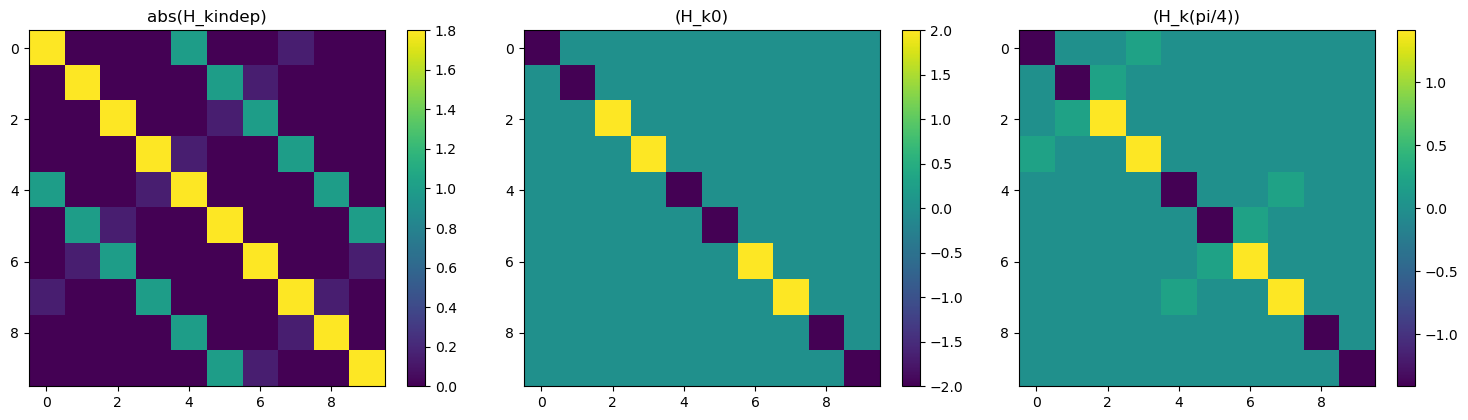

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

im0 = axs[0].imshow(np.abs(H.build_H_kindep())[0:10, 0:10])
axs[0].set_title("abs(H_kindep)")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(np.real(H.build_H_k0())[0:10, 0:10])
axs[1].set_title("(H_k0)")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(np.real(H.build_H_k(PI/4))[0:10, 0:10])
axs[2].set_title("(H_k(pi/4))")
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()


In [12]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000, verbose=True, temperature=T)

Iteration 1:
F0:
Absolute error: 4.450691130177055e-16
Relative error: 0.00044506911301770547
Average old: 0j
Average: (4.7070420267919804e-17+0j)
F_xplus:
Absolute error: 0.059454516234338096
Relative error: 0.5945451623374354
Average old: (0.09999999999999999+0j)
Average: (0.080677391462391+0j)
F_xmin:
Absolute error: 0.05945451623433898
Relative error: 0.5945451623493352
Average old: (-0.09999999999999999+0j)
Average: (-0.08067739146239071+0j)
F_yplus:
Absolute error: 0.05362587597500663
Relative error: 0.5362587597500663
Average old: 0.1j
Average: (-2.8498298589554893e-18+0.08305978517776419j)
F_ymin:
Absolute error: 0.05362587597500663
Relative error: 0.5362587597500663
Average old: -0.1j
Average: (-2.8498298589554893e-18-0.08305978517776419j)
Iteration 2:
F0:
Absolute error: 2.8848474872411687e-16
Relative error: 0.0002884671187088522
Average old: (4.7070420267919804e-17+0j)
Average: (-2.057195472913947e-17+0j)
F_xplus:
Absolute error: 0.0452951847786134
Relative error: 0.5727237

In [13]:
F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

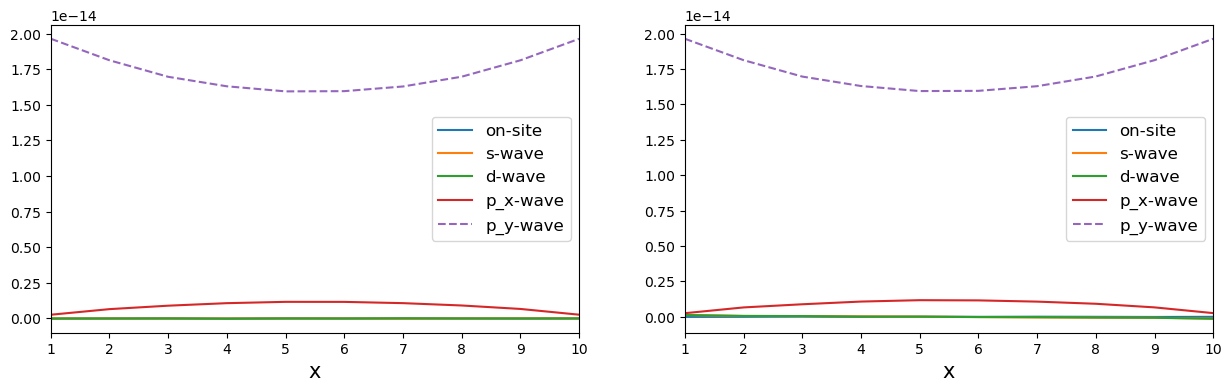

In [14]:
x = np.arange(1, 10 + 1)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(x, np.real(F0), label="on-site")
axs[0].plot(x, np.real(F_swave), label="s-wave")
axs[0].plot(x, np.real(F_dwave), label="d-wave")
axs[0].plot(x, np.real(F_px), label="p_x-wave")
axs[0].plot(x, np.imag(F_py), "--", label="p_y-wave")
axs[0].set_xlabel("x", fontsize=15)
axs[0].set_xlim(1, 10)
axs[0].legend(fontsize=12, loc="best")

axs[1].plot(x, np.real(F0), label="on-site")
axs[1].plot(x, np.real(F_swave2), label="s-wave")
axs[1].plot(x, np.real(F_dwave2), label="d-wave")
axs[1].plot(x, np.real(F_px2), label="p_x-wave")
axs[1].plot(x, np.imag(F_py2), "--", label="p_y-wave")
axs[1].set_xlabel("x", fontsize=15)
axs[1].set_xlim(1, 10)
axs[1].legend(fontsize=12, loc="best")

plt.show()